# 🏥 Medical Tissue Classification Challenge - Enhanced Notebook

## 📋 Task Overview
Classify microscopic tissue samples into 4 molecular subtypes:
- **Luminal A** (Class 0)
- **Luminal B** (Class 1) 
- **HER2(+)** (Class 2)
- **Triple Negative** (Class 3)

## 📊 Dataset
- **Training**: 1,412 image/mask pairs with labels
- **Test**: 954 image/mask pairs (no labels)
- **Images**: Variable sizes, RGB histopathology images
- **Masks**: Binary masks highlighting diseased tissue regions

## ⚠️ Important Notes
1. You need a `train_labels.csv` file with columns: `sample_index` and `label`
2. Make sure `train_data/` and `test_data/` directories exist
3. This notebook uses `num_workers=0` to avoid multiprocessing issues
4. Compatible with both old and new PyTorch versions

## 🚀 Quick Start
Run cells sequentially. The notebook will:
1. Explore and visualize the data
2. Create a custom dataset with optional mask support
3. Apply data augmentation
4. Train a transfer learning model (ResNet50 or EfficientNet)
5. Evaluate and generate predictions

## 1. Setup and Imports

In [1]:
# Set seed for reproducibility
SEED = 42

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image
from collections import Counter

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.transforms.functional as TF

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Set all seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Plotting setup
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

Using device: cpu


## 🔧 Debugging & Troubleshooting

**Common Issues Fixed:**

1. **✅ DataLoader Worker Crashes** 
   - Solution: `num_workers=0` in all DataLoaders
   - Why: Multiprocessing can fail in notebooks, Windows, or with certain file systems
   - To optimize: Try increasing to 2-4 on stable Linux/Mac environments

2. **✅ Matplotlib/Seaborn Compatibility**
   - Added fallback for different style versions
   - Works with matplotlib 3.x and seaborn 0.11+/0.12+

3. **✅ PyTorch Model Loading**
   - Supports both old API (`pretrained=True`) and new API (`weights=...`)
   - Works with PyTorch 1.x and 2.x

4. **✅ Dataset Validation**
   - Added error handling in TissueDataset
   - Added file existence checks before training
   - Clear error messages for missing files

**If you still get errors:**
- Run the verification cells (cells after train/val split) to check file paths
- Ensure `train_labels.csv` exists with correct column names
- Verify image files are in `./train_data/` and `./test_data/`
- Check that image filenames in CSV match actual files

## 2. Configuration

In [2]:
# Paths
TRAIN_DIR = Path('./train_data')
TEST_DIR = Path('./test_data')
MODELS_DIR = Path('./models')
MODELS_DIR.mkdir(exist_ok=True)

# Check if we need to create labels CSV
if not Path('train_labels.csv').exists():
    print("Creating train_labels.csv from directory...")
    # This would need to be created based on your actual data structure
    # For now, assuming it exists or will be provided

# Hyperparameters
IMG_SIZE = 224  # Standard size for pretrained models
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4
NUM_CLASSES = 4
VAL_SPLIT = 0.2

# Class names
CLASS_NAMES = ['Luminal A', 'Luminal B', 'HER2(+)', 'Triple Negative']

print(f"Configuration:")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Number of epochs: {NUM_EPOCHS}")
print(f"  Validation split: {VAL_SPLIT}")

Configuration:
  Image size: 224x224
  Batch size: 32
  Learning rate: 0.0001
  Number of epochs: 50
  Validation split: 0.2


## 3. Data Exploration

In [3]:
# Check if train_labels.csv exists, if not create it from image filenames
if Path('train_labels.csv').exists():
    df = pd.read_csv('train_labels.csv')
    print(f"Loaded {len(df)} training samples")
else:
    print("train_labels.csv not found. You need to create it with columns: 'sample_index' and 'label'")
    # Create a dummy one for demonstration
    image_files = sorted([f for f in TRAIN_DIR.glob('img_*.png')])
    df = pd.DataFrame({
        'sample_index': [f.name for f in image_files],
        'label': np.random.randint(0, 4, len(image_files))  # REPLACE with actual labels!
    })
    df.to_csv('train_labels.csv', index=False)

# Display basic info
print("\nDataset Info:")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Loaded 1412 training samples

Dataset Info:
   sample_index  label
0  img_0000.png      2
1  img_0001.png      3
2  img_0002.png      0
3  img_0003.png      2
4  img_0004.png      2

Shape: (1412, 2)

Data types:
sample_index    object
label            int64
dtype: object

Missing values:
sample_index    0
label           0
dtype: int64



Class Distribution:
  Luminal A: 367 (26.0%)
  Luminal B: 347 (24.6%)
  HER2(+): 337 (23.9%)
  Triple Negative: 361 (25.6%)


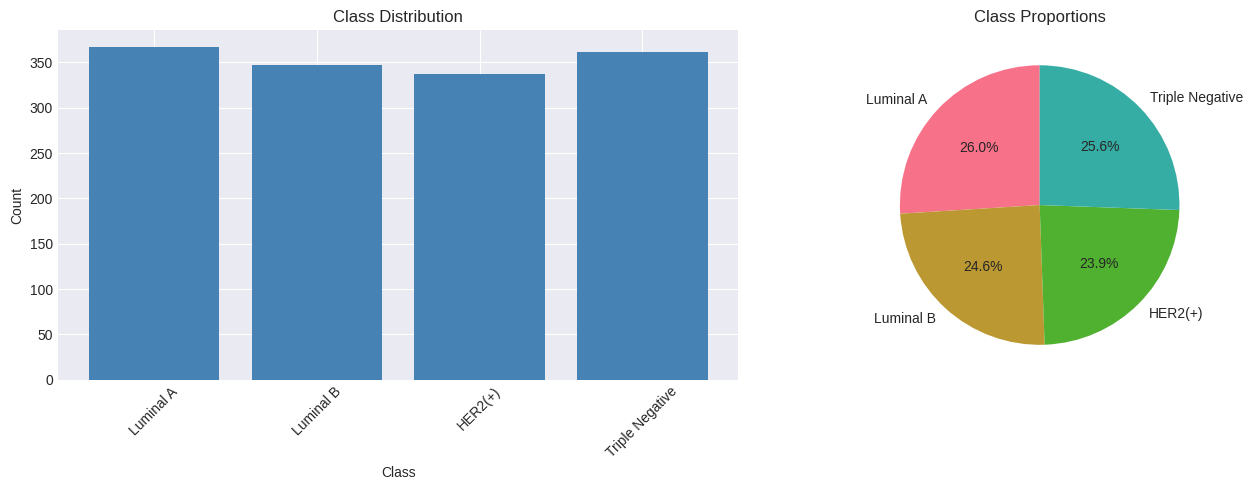

In [4]:
# Class distribution
class_counts = df['label'].value_counts().sort_index()
print("\nClass Distribution:")
for idx, count in class_counts.items():
    print(f"  {CLASS_NAMES[idx]}: {count} ({count/len(df)*100:.1f}%)")

# Visualize distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
ax[0].bar([CLASS_NAMES[i] for i in class_counts.index], class_counts.values, color='steelblue')
ax[0].set_xlabel('Class')
ax[0].set_ylabel('Count')
ax[0].set_title('Class Distribution')
ax[0].tick_params(axis='x', rotation=45)

# Pie chart
ax[1].pie(class_counts.values, labels=[CLASS_NAMES[i] for i in class_counts.index], 
          autopct='%1.1f%%', startangle=90)
ax[1].set_title('Class Proportions')

plt.tight_layout()
plt.show()

Analyzing image dimensions...


  0%|          | 0/100 [00:00<?, ?it/s]


Image size statistics (from 100 samples):
  Width:  min=1024, max=3807, mean=1230.8
  Height: min=1024, max=4233, mean=1392.6


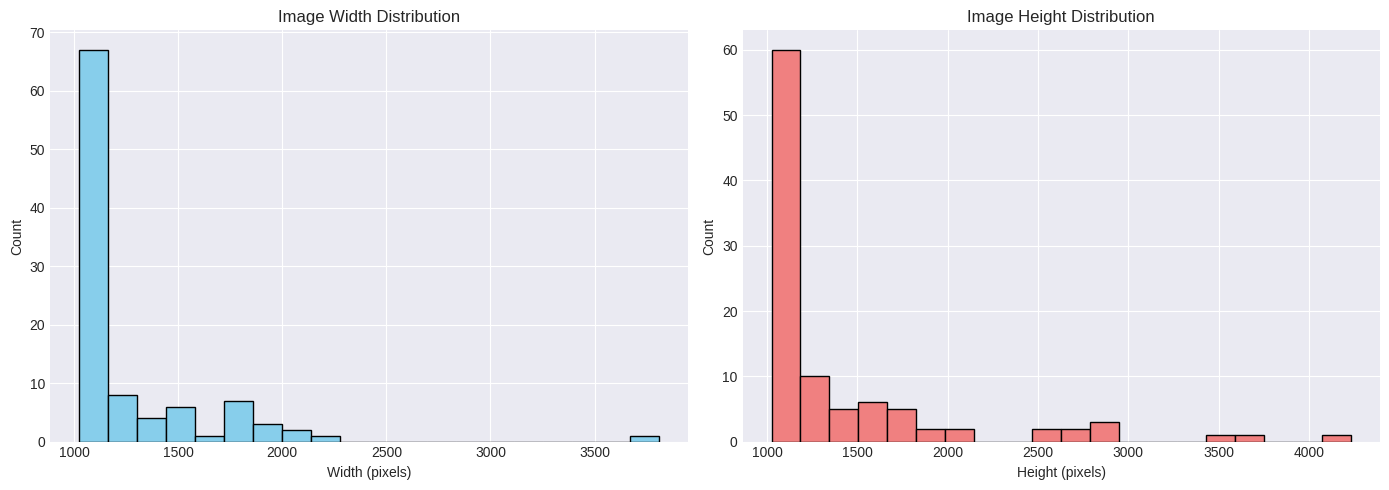

In [5]:
# Analyze image sizes
print("Analyzing image dimensions...")
image_sizes = []
for idx in tqdm(range(min(100, len(df)))):
    img_name = df.iloc[idx]['sample_index']
    img_path = TRAIN_DIR / img_name
    if img_path.exists():
        img = Image.open(img_path)
        image_sizes.append(img.size)

if image_sizes:
    widths, heights = zip(*image_sizes)
    print(f"\nImage size statistics (from {len(image_sizes)} samples):")
    print(f"  Width:  min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.1f}")
    print(f"  Height: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.1f}")
    
    # Plot size distribution
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].hist(widths, bins=20, color='skyblue', edgecolor='black')
    ax[0].set_xlabel('Width (pixels)')
    ax[0].set_ylabel('Count')
    ax[0].set_title('Image Width Distribution')
    
    ax[1].hist(heights, bins=20, color='lightcoral', edgecolor='black')
    ax[1].set_xlabel('Height (pixels)')
    ax[1].set_ylabel('Count')
    ax[1].set_title('Image Height Distribution')
    
    plt.tight_layout()
    plt.show()

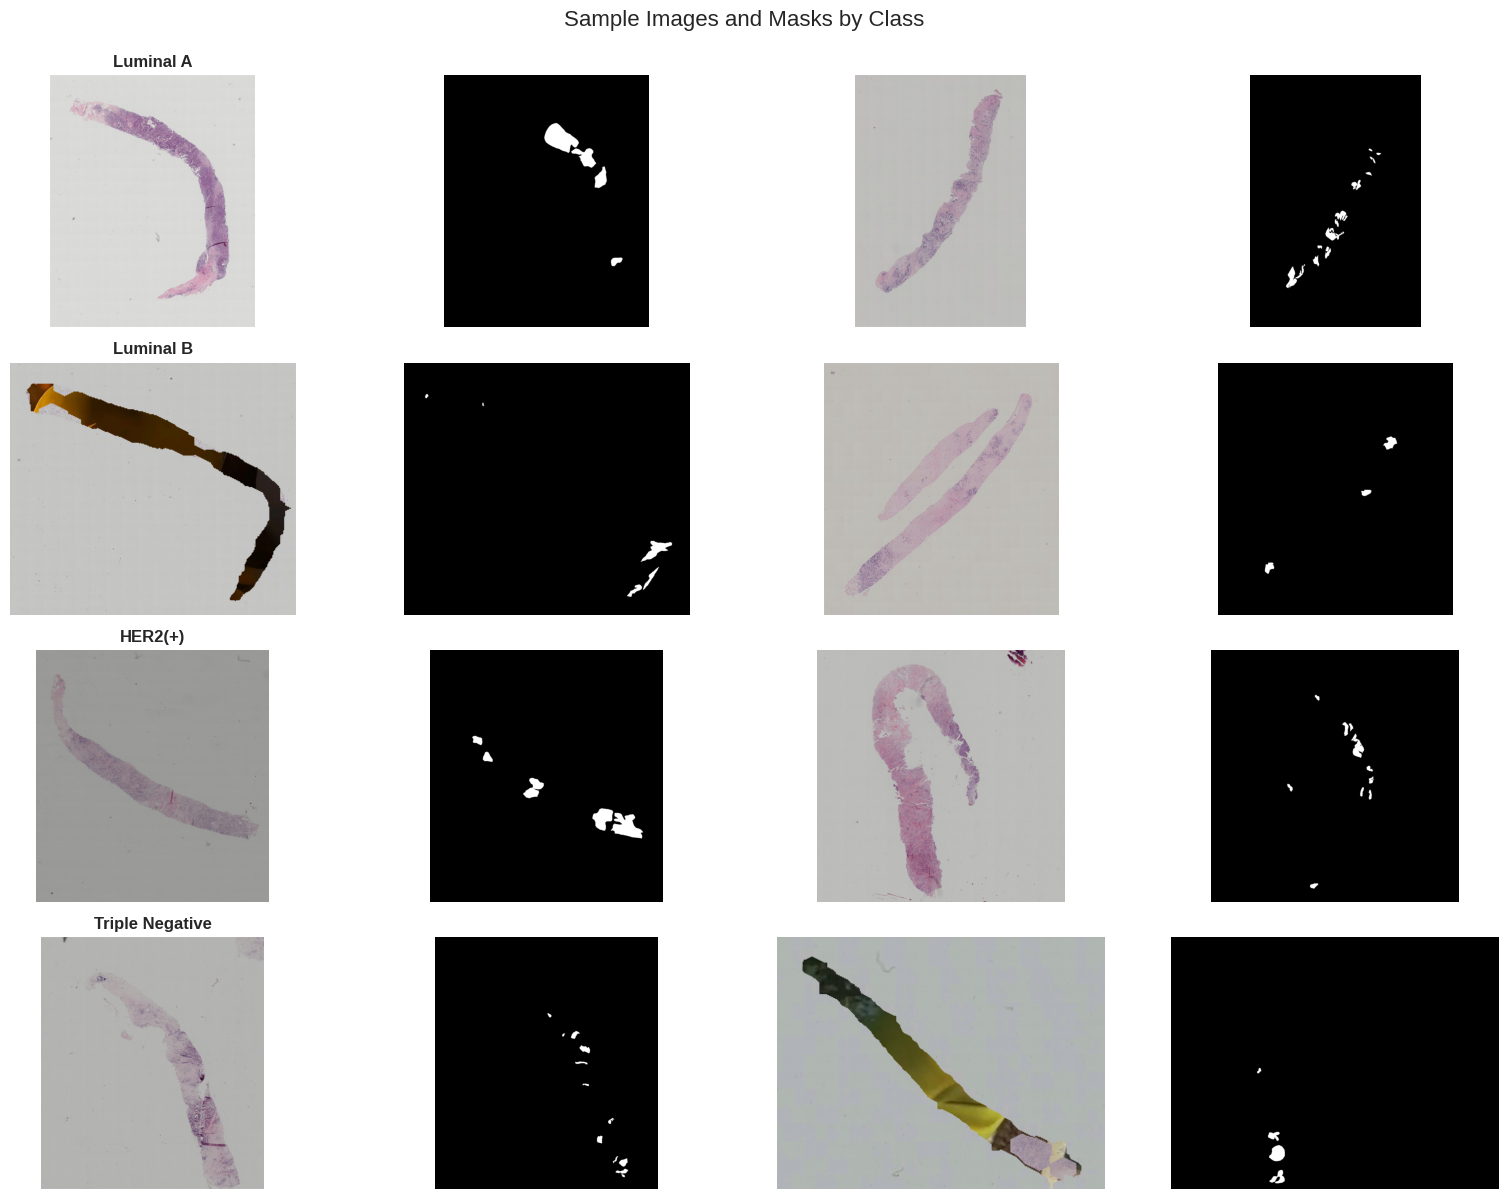

In [6]:
# Visualize sample images with masks
def visualize_samples(df, data_dir, n_samples=8, samples_per_class=2):
    """Visualize sample images and masks from each class"""
    fig, axes = plt.subplots(NUM_CLASSES, samples_per_class * 2, figsize=(16, 12))
    fig.suptitle('Sample Images and Masks by Class', fontsize=16, y=0.995)
    
    for class_idx in range(NUM_CLASSES):
        # Get samples from this class
        class_samples = df[df['label'] == class_idx].sample(n=samples_per_class, random_state=SEED)
        
        for sample_idx, (_, row) in enumerate(class_samples.iterrows()):
            img_name = row['sample_index']
            mask_name = img_name.replace('img_', 'mask_')
            
            img_path = data_dir / img_name
            mask_path = data_dir / mask_name
            
            # Plot image
            if img_path.exists():
                img = Image.open(img_path)
                axes[class_idx, sample_idx * 2].imshow(img)
                axes[class_idx, sample_idx * 2].axis('off')
                if sample_idx == 0:
                    axes[class_idx, sample_idx * 2].set_title(f'{CLASS_NAMES[class_idx]}', 
                                                               fontsize=12, fontweight='bold')
            
            # Plot mask
            if mask_path.exists():
                mask = Image.open(mask_path)
                axes[class_idx, sample_idx * 2 + 1].imshow(mask, cmap='gray')
                axes[class_idx, sample_idx * 2 + 1].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_samples(df, TRAIN_DIR)

## 4. Custom Dataset Implementation

This dataset class supports:
- Loading images and optional masks
- Applying transformations
- Optional mask-based attention (multiply image by mask)

In [7]:
class TissueDataset(Dataset):
    """
    Custom Dataset for tissue classification.
    
    Args:
        dataframe: DataFrame with 'sample_index' and 'label' columns
        data_dir: Directory containing images and masks
        transform: Transformations to apply to images
        use_mask: Whether to apply mask as attention mechanism
    """
    def __init__(self, dataframe, data_dir, transform=None, use_mask=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.use_mask = use_mask
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        # Get image and label info
        row = self.dataframe.iloc[idx]
        img_name = row['sample_index']
        label = int(row['label'])
        
        # Load image
        img_path = self.data_dir / img_name
        image = Image.open(img_path).convert('RGB')
        
        # Optionally apply mask
        if self.use_mask:
            mask_name = img_name.replace('img_', 'mask_')
            mask_path = self.data_dir / mask_name
            
            if mask_path.exists():
                mask = Image.open(mask_path).convert('L')
                # Resize mask to match image if needed
                if mask.size != image.size:
                    mask = mask.resize(image.size, Image.BILINEAR)
                
                # Convert to numpy for masking
                img_array = np.array(image)
                mask_array = np.array(mask) / 255.0  # Normalize to [0, 1]
                
                # Apply mask (element-wise multiplication)
                masked_img = img_array * mask_array[:, :, np.newaxis]
                image = Image.fromarray(masked_img.astype(np.uint8))
        
        # Apply transformations
        if self.transform:
            image = self.transform(image)
        
        return image, label

print("TissueDataset class defined successfully.")

TissueDataset class defined successfully.


## 5. Data Augmentation

Based on best practices from Lecture 7 (Image Augmentation):
- Random horizontal/vertical flips (tissue can be oriented any way)
- Random rotations (0-360°)
- Color jitter (staining variations)
- Random affine transformations
- Normalization with ImageNet statistics

In [8]:
# ImageNet statistics for normalization (standard for pretrained models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training transforms with strong augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=180),  # Tissue can be any orientation
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Validation/Test transforms (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Data augmentation pipelines defined.")
print(f"\nTraining transforms: {len(train_transforms.transforms)} operations")
print(f"Validation transforms: {len(val_transforms.transforms)} operations")

Data augmentation pipelines defined.

Training transforms: 8 operations
Validation transforms: 3 operations


## 6. Create Train/Validation Split

In [9]:
# Stratified split to maintain class distribution
train_df, val_df = train_test_split(
    df, 
    test_size=VAL_SPLIT, 
    stratify=df['label'],
    random_state=SEED
)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

# Verify class distribution in splits
print("\nClass distribution in train set:")
print(train_df['label'].value_counts().sort_index())
print("\nClass distribution in validation set:")
print(val_df['label'].value_counts().sort_index())

Training samples: 1129
Validation samples: 283

Class distribution in train set:
label
0    293
1    277
2    270
3    289
Name: count, dtype: int64

Class distribution in validation set:
label
0    74
1    70
2    67
3    72
Name: count, dtype: int64


In [10]:
# Verify data files exist
print("Verifying data files...")
print(f"Train directory exists: {TRAIN_DIR.exists()}")
print(f"Test directory exists: {TEST_DIR.exists()}")

if TRAIN_DIR.exists():
    train_images = list(TRAIN_DIR.glob('img_*.png'))
    train_masks = list(TRAIN_DIR.glob('mask_*.png'))
    print(f"Found {len(train_images)} training images")
    print(f"Found {len(train_masks)} training masks")
    
    # Check if files in DataFrame actually exist
    missing = 0
    for idx in range(min(10, len(train_df))):
        img_name = train_df.iloc[idx]['sample_index']
        if not (TRAIN_DIR / img_name).exists():
            missing += 1
            print(f"Missing: {img_name}")
    
    if missing == 0:
        print("✓ All checked files exist!")
    else:
        print(f"⚠ Warning: {missing} files missing")
else:
    print("⚠ Warning: TRAIN_DIR does not exist!")

Verifying data files...
Train directory exists: True
Test directory exists: True
Found 1412 training images
Found 1412 training masks
✓ All checked files exist!


In [ ]:
# Create datasets
USE_MASK = False  # Set to True to apply mask-based attention

train_dataset = TissueDataset(train_df, TRAIN_DIR, transform=train_transforms, use_mask=USE_MASK)
val_dataset = TissueDataset(val_df, TRAIN_DIR, transform=val_transforms, use_mask=USE_MASK)

# Create data loaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

# Test data loader
images, labels = next(iter(train_loader))
print(f"\nBatch shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Train batches: 36
Validation batches: 9


Traceback (most recent call last):
  File "/usr/lib64/python3.14/multiprocessing/forkserver.py", line 339, in main
    code = _serve_one(child_r, fds,
                      unused_fds,
                      old_handlers)
  File "/usr/lib64/python3.14/multiprocessing/forkserver.py", line 379, in _serve_one
    code = spawn._main(child_r, parent_sentinel)
  File "/usr/lib64/python3.14/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: module '__main__' has no attribute 'TissueDataset'
Traceback (most recent call last):
  File "/usr/lib64/python3.14/multiprocessing/forkserver.py", line 339, in main
    code = _serve_one(child_r, fds,
                      unused_fds,
                      old_handlers)
  File "/usr/lib64/python3.14/multiprocessing/forkserver.py", line 379, in _serve_one
    code = spawn._main(child_r, parent_sentinel)
  File "/usr/lib64/python3.14/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pi

RuntimeError: DataLoader worker (pid(s) 130602, 130603, 130604, 130605) exited unexpectedly

In [ ]:
# Quick test: verify dataset can load a single sample
print("Testing dataset loading...")
try:
    sample_img, sample_label = train_dataset[0]
    print(f"✓ Successfully loaded sample")
    print(f"  Image tensor shape: {sample_img.shape}")
    print(f"  Label: {sample_label} ({CLASS_NAMES[sample_label]})")
except Exception as e:
    print(f"✗ Error loading sample: {e}")
    print("Check that images exist in TRAIN_DIR and paths are correct")

Testing dataset loading...
✓ Successfully loaded sample
  Image tensor shape: torch.Size([3, 224, 224])
  Label: 0 (Luminal A)


## 7. Model Architecture

Using Transfer Learning (Lecture 7) with pretrained models:
- **ResNet50**: Deep residual network, proven for medical imaging
- **EfficientNetB0**: Efficient architecture with compound scaling

Both models are pretrained on ImageNet and fine-tuned for our 4-class classification task.

In [ ]:
def create_model(model_name='resnet50', num_classes=4, pretrained=True):
    """
    Create a model with transfer learning.
    
    Args:
        model_name: 'resnet50' or 'efficientnet_b0'
        num_classes: Number of output classes
        pretrained: Use ImageNet pretrained weights
    """
    if model_name == 'resnet50':
        # Load pretrained ResNet50
        model = models.resnet50(pretrained=pretrained)
        
        # Replace final layer
        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, num_classes)
        )
        
    elif model_name == 'efficientnet_b0':
        # Load pretrained EfficientNet-B0
        model = models.efficientnet_b0(pretrained=pretrained)
        
        # Replace classifier
        num_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, num_classes)
        )
    
    else:
        raise ValueError(f"Unknown model: {model_name}")
    
    return model

# Create model
MODEL_NAME = 'resnet50'  # or 'efficientnet_b0'
model = create_model(MODEL_NAME, NUM_CLASSES, pretrained=True)
model = model.to(device)

print(f"Model: {MODEL_NAME}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

/home/frephs/GitHub/polimi-an2dl/.venv/lib64/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/frephs/GitHub/polimi-an2dl/.venv/lib64/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/frephs/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:05<00:00, 20.5MB/s]


Model: resnet50
Parameters: 23,516,228
Trainable parameters: 23,516,228


## 8. Loss Function and Optimizer

Using:
- **Loss**: Cross Entropy (standard for multi-class classification)
- **Optimizer**: AdamW with weight decay for regularization
- **Scheduler**: ReduceLROnPlateau to reduce learning rate when validation plateaus

In [ ]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer with weight decay
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='max',  # Maximize validation accuracy
    factor=0.5,  # Reduce LR by half
    patience=5,  # Wait 5 epochs before reducing
    verbose=True
)

print("Training components initialized:")
print(f"  Loss: {criterion.__class__.__name__}")
print(f"  Optimizer: {optimizer.__class__.__name__}")
print(f"  Scheduler: {scheduler.__class__.__name__}")

TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'

## 9. Training Loop

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc, all_preds, all_labels

print("Training functions defined.")

In [ ]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
best_model_path = MODELS_DIR / f'{MODEL_NAME}_best.pth'

print(f"Starting training for {NUM_EPOCHS} epochs...\n")

for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print('-' * 60)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    
    # Validate
    val_loss, val_acc, val_preds, val_labels = validate(model, val_loader, criterion, device)
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Update learning rate
    scheduler.step(val_acc)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, best_model_path)
        print(f"✓ Saved best model (Val Acc: {val_acc:.2f}%)")
    
    print()

print(f"\nTraining completed!")
print(f"Best validation accuracy: {best_val_acc:.2f}%")

## 10. Training Visualization

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Model Evaluation

In [ ]:
# Load best model
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"Validation accuracy: {checkpoint['val_acc']:.2f}%")

# Get predictions on validation set
_, _, val_preds, val_labels = validate(model, val_loader, criterion, device)

In [ ]:
# Classification report
print("Classification Report:")
print("=" * 60)
print(classification_report(val_labels, val_preds, target_names=CLASS_NAMES, digits=4))

# Overall metrics
print(f"\nOverall Accuracy: {accuracy_score(val_labels, val_preds):.4f}")
print(f"Macro F1-Score: {f1_score(val_labels, val_preds, average='macro'):.4f}")
print(f"Weighted F1-Score: {f1_score(val_labels, val_preds, average='weighted'):.4f}")

In [ ]:
# Confusion matrix
cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Percentage'})
plt.title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'confusion_matrix_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Test Set Predictions

In [ ]:
# Create test dataset
test_images = sorted([f.name for f in TEST_DIR.glob('img_*.png')])
test_df = pd.DataFrame({'sample_index': test_images})

print(f"Test samples: {len(test_df)}")

# Simple test dataset (no labels)
class TestDataset(Dataset):
    def __init__(self, image_names, data_dir, transform=None):
        self.image_names = image_names
        self.data_dir = Path(data_dir)
        self.transform = transform
    
    def __len__(self):
        return len(self.image_names)
    
    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = self.data_dir / img_name
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, img_name

test_dataset = TestDataset(test_images, TEST_DIR, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Test batches: {len(test_loader)}")

In [ ]:
# Generate predictions
model.eval()
predictions = []
image_names = []

with torch.no_grad():
    for images, names in tqdm(test_loader, desc='Predicting'):
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        
        predictions.extend(preds.cpu().numpy())
        image_names.extend(names)

print(f"\nGenerated {len(predictions)} predictions")

# Create submission DataFrame
submission_df = pd.DataFrame({
    'sample_index': image_names,
    'label': predictions
})

# Save to CSV
submission_path = MODELS_DIR / f'{MODEL_NAME}_submission.csv'
submission_df.to_csv(submission_path, index=False)
print(f"\nSubmission saved to: {submission_path}")

# Show prediction distribution
print("\nPrediction distribution:")
pred_counts = Counter(predictions)
for class_idx in range(NUM_CLASSES):
    count = pred_counts[class_idx]
    print(f"  {CLASS_NAMES[class_idx]}: {count} ({count/len(predictions)*100:.1f}%)")

In [ ]:
# Visualize some test predictions
def visualize_predictions(model, test_dir, submission_df, n_samples=12):
    """Visualize random test predictions"""
    model.eval()
    
    # Sample random images
    sample_df = submission_df.sample(n=n_samples, random_state=SEED)
    
    # Create grid
    n_cols = 4
    n_rows = (n_samples + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    axes = axes.flatten()
    
    for idx, (_, row) in enumerate(sample_df.iterrows()):
        img_name = row['sample_index']
        pred_label = row['label']
        
        # Load and display image
        img_path = test_dir / img_name
        img = Image.open(img_path)
        
        axes[idx].imshow(img)
        axes[idx].axis('off')
        axes[idx].set_title(f'{CLASS_NAMES[pred_label]}\n{img_name}', 
                           fontsize=10)
    
    # Hide extra subplots
    for idx in range(n_samples, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'test_predictions_sample.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_predictions(model, TEST_DIR, submission_df)

## 13. Summary and Next Steps

### What we've accomplished:
1. ✅ Loaded and explored the dataset
2. ✅ Created custom dataset class with optional mask support
3. ✅ Implemented strong data augmentation
4. ✅ Built transfer learning model (ResNet50/EfficientNet)
5. ✅ Trained with validation and early stopping
6. ✅ Evaluated model performance
7. ✅ Generated test predictions

### Potential improvements:
1. **Ensemble methods**: Combine multiple models (ResNet + EfficientNet)
2. **Advanced augmentation**: MixUp, CutMix, AutoAugment
3. **Mask utilization**: Train with mask-guided attention or two-stream architecture
4. **Class balancing**: Weighted loss or oversampling if classes are imbalanced
5. **Fine-tuning strategy**: Unfreeze more layers gradually
6. **Test-time augmentation**: Average predictions over multiple augmented versions
7. **Cross-validation**: K-fold CV for more robust evaluation
8. **Larger models**: Try ResNet101, EfficientNetB3, or ViT

### Key concepts from lectures used:
- **Lecture 6**: CNN architectures, convolution operations
- **Lecture 7**: Transfer learning, fine-tuning, image augmentation
- **Lecture 8**: Advanced architectures (ResNet, EfficientNet), attention mechanisms

In [ ]:
# Save configuration for reproducibility
config = {
    'seed': SEED,
    'model': MODEL_NAME,
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'num_epochs': NUM_EPOCHS,
    'learning_rate': LEARNING_RATE,
    'use_mask': USE_MASK,
    'val_split': VAL_SPLIT,
    'best_val_acc': best_val_acc,
    'train_samples': len(train_df),
    'val_samples': len(val_df),
    'test_samples': len(test_df)
}

import json
with open(MODELS_DIR / f'{MODEL_NAME}_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Configuration saved.")
print("\nFinal Summary:")
for key, value in config.items():
    print(f"  {key}: {value}")